<a href="https://colab.research.google.com/github/minhasaleem/Deep-Vision-AI-Workshop/blob/main/Day3_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip /content/dogcat.zip -d /content/dogcat

Archive:  /content/dogcat.zip
   creating: /content/dogcat/dogcat/
  inflating: /content/dogcat/dogcat/c1.jpg  
  inflating: /content/dogcat/dogcat/c10.jpg  
  inflating: /content/dogcat/dogcat/c2.jpg  
  inflating: /content/dogcat/dogcat/c3.jpg  
  inflating: /content/dogcat/dogcat/c4.jpg  
  inflating: /content/dogcat/dogcat/c5.jpg  
  inflating: /content/dogcat/dogcat/c6.jpg  
  inflating: /content/dogcat/dogcat/c7.jpg  
  inflating: /content/dogcat/dogcat/c8.jpg  
  inflating: /content/dogcat/dogcat/c9.jpg  
  inflating: /content/dogcat/dogcat/d1.jpg  
  inflating: /content/dogcat/dogcat/d10.jpg  
  inflating: /content/dogcat/dogcat/d2.jpg  
  inflating: /content/dogcat/dogcat/d3.jpg  
  inflating: /content/dogcat/dogcat/d4.jpg  
  inflating: /content/dogcat/dogcat/d5.jpg  
  inflating: /content/dogcat/dogcat/d6.jpg  
  inflating: /content/dogcat/dogcat/d7.jpg  
  inflating: /content/dogcat/dogcat/d8.jpg  
  inflating: /content/dogcat/dogcat/d9.jpg  


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [11]:
image_folder = "/content/dogcat/dogcat"# while zipping,one more folder called dogcat was again created, there for two dogcat

images = []  # This list will store the image data.
labels = []  # This list stores the class of each image. (cat=0, dog=1)

for filename in os.listdir(image_folder):

    if filename.endswith((".jpg", ".png", ".jpeg")):

        img_path = os.path.join(image_folder, filename)  # Complete path

        img = cv2.imread(img_path)      # Read the image
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224,224))

        images.append(img)  # Store the processed image

        # Label creation
        if filename.startswith("c"):
            labels.append(0)      # Cat
            print(filename, "-> Label: 0 (Cat)")

        elif filename.startswith("d"):
            labels.append(1)      # Dog
            print(filename, "-> Label: 1 (Dog)")

print("\nAll Labels:", labels)

c3.jpg -> Label: 0 (Cat)
c7.jpg -> Label: 0 (Cat)
c8.jpg -> Label: 0 (Cat)
d6.jpg -> Label: 1 (Dog)
c6.jpg -> Label: 0 (Cat)
d8.jpg -> Label: 1 (Dog)
d2.jpg -> Label: 1 (Dog)
c1.jpg -> Label: 0 (Cat)
c10.jpg -> Label: 0 (Cat)
d1.jpg -> Label: 1 (Dog)
c5.jpg -> Label: 0 (Cat)
d3.jpg -> Label: 1 (Dog)
d10.jpg -> Label: 1 (Dog)
d7.jpg -> Label: 1 (Dog)
d9.jpg -> Label: 1 (Dog)
d5.jpg -> Label: 1 (Dog)
c4.jpg -> Label: 0 (Cat)
d4.jpg -> Label: 1 (Dog)
c2.jpg -> Label: 0 (Cat)
c9.jpg -> Label: 0 (Cat)

All Labels: [0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0]


In [12]:
print("Total Images:", len(images))
print("Total Labels:", len(labels))

Total Images: 20
Total Labels: 20


In [13]:
#convert to numpy arrays(list to array)
X = np.array(images)
y = np.array(labels)

print(X.shape)
print(y)

(20, 224, 224, 3)
[0 0 0 1 0 1 1 0 0 1 0 1 1 1 1 1 0 1 0 0]


In [14]:
#normalization
#usually the value is b/w 0 to 255,but it is easier for the neural networks to work,if the pixels are b/w 0 and 1
X = X / 255.0

In [16]:
#Flatten the images(Logistic Regression and Naive Bayes cannot accept 4D image data. They expect a 2D matrix (samples, features).)
X = X.reshape(20, -1)

In [17]:
print(X.shape)

(20, 150528)


In [19]:
#train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB() #create the model
model.fit(X_train, y_train)#trains the model with the data that is given above

GaussianNB()

In [36]:
y_pred = model.predict(X_test)#predict based on the test data

In [37]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)#find accuracy from the actual and the predicted
print("Accuracy:", accuracy)

Accuracy: 0.5


In [20]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

In [21]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5


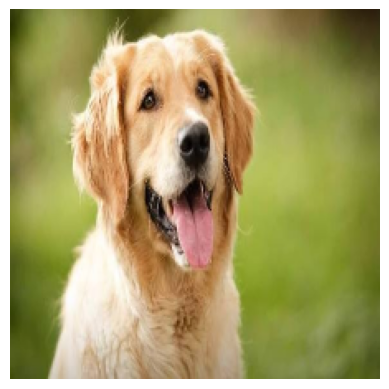

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("testdog.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224,224))

plt.imshow(img)
plt.axis("off")
plt.show()

img = img / 255.0          # Normalize
img = img.reshape(1, -1)   # Flatten

In [32]:
prediction = model.predict(img)
print("Prediction:", prediction)

Prediction: [1]


In [34]:
if prediction[0] == 0:
    print("Cat")
else:
    print("Dog")

Dog
